## Cell 1 — Imports

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os, time
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    f1_score, accuracy_score, recall_score, precision_score,
    classification_report, confusion_matrix
)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import cohen_kappa_score
from scipy.stats import spearmanr
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import shap
import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)

RANDOM_STATE = 42
N_TRIALS     = 50
DATA_PATH    = 'final_processed_data.csv'
SCALED_MODELS = {'SVM', 'LogisticRegression'}
os.makedirs("output", exist_ok=True)

print("✓ Libraries imported successfully.")

✓ Libraries imported successfully.


## Cell 2 — Load Data

In [2]:
df = pd.read_csv(DATA_PATH)

X = df.drop(columns=['target_fertilizer'])
y = df['target_fertilizer'].values

CLASS_MAP = {
    0: 'Balanced NPK Fertilizer',
    1: 'Compost',
    2: 'DAP',
    3: 'General Purpose Fertilizer',
    4: 'Gypsum',
    5: 'Lime',
    6: 'Muriate of Potash',
    7: 'Organic Fertilizer',
    8: 'Urea',
    9: 'Water Retaining Fertilizer',
}

N_CLASSES = len(np.unique(y))
print(f"✓ Dataset loaded: {X.shape[0]} rows, {X.shape[1]} features, {N_CLASSES} classes.")

✓ Dataset loaded: 3100 rows, 44 features, 10 classes.


## Cell 3 — Split, Scale & Weights

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
X_train = X_train.reset_index(drop=True)
X_test  = X_test.reset_index(drop=True)

sample_weights = compute_sample_weight('balanced', y_train)

X_train_arr = X_train.values
X_test_arr  = X_test.values

scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_arr)
X_test_scaled  = scaler.transform(X_test_arr)

print(f"✓ Split — Train: {X_train_arr.shape}, Test: {X_test_arr.shape}")
print("✓ Balanced sample weights computed.")
print("✓ StandardScaler fitted.")

✓ Split — Train: (2480, 44), Test: (620, 44)
✓ Balanced sample weights computed.
✓ StandardScaler fitted.


## Cell 4 — Optuna Objective Functions

In [4]:
def cv_macro_f1(model, X, y, sw, cv_folds=5):
    skf = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=RANDOM_STATE)
    scores = []
    for train_idx, val_idx in skf.split(X, y):
        model.fit(X[train_idx], y[train_idx], sample_weight=sw[train_idx])
        preds = model.predict(X[val_idx])
        scores.append(f1_score(y[val_idx], preds, average='macro', zero_division=0))
    return np.mean(scores)


def rf_objective(trial):
    model = RandomForestClassifier(
        n_estimators      = trial.suggest_int('n_estimators', 200, 1000, step=50),
        max_depth         = trial.suggest_int('max_depth', 3, 20),
        min_samples_split = trial.suggest_int('min_samples_split', 2, 20),
        min_samples_leaf  = trial.suggest_int('min_samples_leaf', 1, 10),
        max_features      = trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        random_state=RANDOM_STATE, n_jobs=1,
    )
    return cv_macro_f1(model, X_train_arr, y_train, sample_weights)


def gb_objective(trial):
    model = GradientBoostingClassifier(
        n_estimators      = trial.suggest_int('n_estimators', 200, 1000, step=50),
        learning_rate     = trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        max_depth         = trial.suggest_int('max_depth', 3, 8),
        subsample         = trial.suggest_float('subsample', 0.6, 1.0),
        max_features      = trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        min_samples_leaf  = trial.suggest_int('min_samples_leaf', 1, 15),
        min_samples_split = trial.suggest_int('min_samples_split', 2, 20),
        random_state=RANDOM_STATE,
    )
    return cv_macro_f1(model, X_train_arr, y_train, sample_weights)


def xgb_objective(trial):
    model = XGBClassifier(
        n_estimators     = trial.suggest_int('n_estimators', 200, 1000, step=50),
        learning_rate    = trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        max_depth        = trial.suggest_int('max_depth', 3, 8),
        subsample        = trial.suggest_float('subsample', 0.6, 1.0),
        colsample_bytree = trial.suggest_float('colsample_bytree', 0.6, 1.0),
        min_child_weight = trial.suggest_int('min_child_weight', 1, 15),
        gamma            = trial.suggest_float('gamma', 0.0, 5.0),
        reg_alpha        = trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        reg_lambda       = trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        eval_metric='mlogloss', tree_method='hist', device='cuda',
        random_state=RANDOM_STATE, n_jobs=1,
    )
    return cv_macro_f1(model, X_train_arr, y_train, sample_weights)


def lgbm_objective(trial):
    model = LGBMClassifier(
        n_estimators      = trial.suggest_int('n_estimators', 200, 1000, step=50),
        learning_rate     = trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        max_depth         = trial.suggest_int('max_depth', 3, 8),
        num_leaves        = trial.suggest_int('num_leaves', 20, 150),
        subsample         = trial.suggest_float('subsample', 0.6, 1.0),
        colsample_bytree  = trial.suggest_float('colsample_bytree', 0.6, 1.0),
        min_child_samples = trial.suggest_int('min_child_samples', 5, 100),
        reg_alpha         = trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        reg_lambda        = trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        device='gpu', verbosity=-1, random_state=RANDOM_STATE, n_jobs=1,
    )
    return cv_macro_f1(model, X_train_arr, y_train, sample_weights)


def svm_objective(trial):
    kernel = trial.suggest_categorical('kernel', ['rbf', 'linear'])
    gamma  = trial.suggest_categorical('gamma', ['scale', 'auto']) if kernel == 'rbf' else 'scale'
    model  = SVC(
        C      = trial.suggest_float('C', 1e-2, 100.0, log=True),
        kernel = kernel,
        gamma  = gamma,
        random_state=RANDOM_STATE,
    )
    return cv_macro_f1(model, X_train_scaled, y_train, sample_weights)


def lr_objective(trial):
    # Combine solver+penalty to avoid invalid combinations (lbfgs only supports l2)
    solver_penalty = trial.suggest_categorical(
        'solver_penalty', ['lbfgs_l2', 'saga_l1', 'saga_l2']
    )
    solver, penalty = solver_penalty.split('_')
    model = LogisticRegression(
        C       = trial.suggest_float('C', 1e-3, 100.0, log=True),
        solver  = solver,
        penalty = penalty,
        max_iter=1000, random_state=RANDOM_STATE, n_jobs=1,
    )
    return cv_macro_f1(model, X_train_scaled, y_train, sample_weights)


# Shared dicts populated by the cells below
studies     = {}
best_params = {}

print("✓ All Optuna objectives defined.")

✓ All Optuna objectives defined.


## Cell 5a — Optimize: Random Forest

In [5]:
study_rf = optuna.create_study(
    direction='maximize',
    study_name='RandomForest_MacroF1',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
)
print("⏳ Optimizing RandomForest...")
study_rf.optimize(rf_objective, n_trials=N_TRIALS, show_progress_bar=True)

studies['RandomForest']     = study_rf
best_params['RandomForest'] = study_rf.best_params.copy()
print(f"✅ RandomForest | Best CV Macro F1: {study_rf.best_value:.4f}")

⏳ Optimizing RandomForest...


Best trial: 24. Best value: 0.954082: 100%|███████████████████████████████████| 50/50 [10:40<00:00, 12.81s/it]

✅ RandomForest | Best CV Macro F1: 0.9541


## Cell 5b — Optimize: Gradient Boosting

In [6]:
study_gb = optuna.create_study(
    direction='maximize',
    study_name='GradientBoosting_MacroF1',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
)
print("⏳ Optimizing GradientBoosting...")
study_gb.optimize(gb_objective, n_trials=N_TRIALS, show_progress_bar=True)

studies['GradientBoosting']     = study_gb
best_params['GradientBoosting'] = study_gb.best_params.copy()
print(f"✅ GradientBoosting | Best CV Macro F1: {study_gb.best_value:.4f}")

⏳ Optimizing GradientBoosting...


Best trial: 15. Best value: 0.951298: 100%|████████████████████████████████| 50/50 [1:48:51<00:00, 130.63s/it]

✅ GradientBoosting | Best CV Macro F1: 0.9513


## Cell 5c — Optimize: XGBoost

In [7]:
study_xgb = optuna.create_study(
    direction='maximize',
    study_name='XGBoost_MacroF1',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
)
print("⏳ Optimizing XGBoost...")
study_xgb.optimize(xgb_objective, n_trials=N_TRIALS, show_progress_bar=True)

studies['XGBoost']     = study_xgb
best_params['XGBoost'] = study_xgb.best_params.copy()
print(f"✅ XGBoost | Best CV Macro F1: {study_xgb.best_value:.4f}")

⏳ Optimizing XGBoost...


Best trial: 49. Best value: 0.953866: 100%|███████████████████████████████████| 50/50 [07:54<00:00,  9.49s/it]

✅ XGBoost | Best CV Macro F1: 0.9539


## Cell 5d — Optimize: LightGBM

In [8]:
study_lgbm = optuna.create_study(
    direction='maximize',
    study_name='LightGBM_MacroF1',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
)
print("⏳ Optimizing LightGBM...")
study_lgbm.optimize(lgbm_objective, n_trials=N_TRIALS, show_progress_bar=True)

studies['LightGBM']     = study_lgbm
best_params['LightGBM'] = study_lgbm.best_params.copy()
print(f"✅ LightGBM | Best CV Macro F1: {study_lgbm.best_value:.4f}")

⏳ Optimizing LightGBM...


Best trial: 38. Best value: 0.952846: 100%|███████████████████████████████████| 50/50 [08:00<00:00,  9.61s/it]

✅ LightGBM | Best CV Macro F1: 0.9528


## Cell 5e — Optimize: SVM

In [9]:
study_svm = optuna.create_study(
    direction='maximize',
    study_name='SVM_MacroF1',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
)
print("⏳ Optimizing SVM...")
study_svm.optimize(svm_objective, n_trials=N_TRIALS, show_progress_bar=True)

studies['SVM']     = study_svm
best_params['SVM'] = study_svm.best_params.copy()
print(f"✅ SVM | Best CV Macro F1: {study_svm.best_value:.4f}")

⏳ Optimizing SVM...


Best trial: 25. Best value: 0.733844: 100%|███████████████████████████████████| 50/50 [01:41<00:00,  2.03s/it]

✅ SVM | Best CV Macro F1: 0.7338


## Cell 5f — Optimize: Logistic Regression

In [10]:
study_lr = optuna.create_study(
    direction='maximize',
    study_name='LogisticRegression_MacroF1',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
)
print("⏳ Optimizing LogisticRegression...")
study_lr.optimize(lr_objective, n_trials=N_TRIALS, show_progress_bar=True)

studies['LogisticRegression'] = study_lr

# Decode the combined solver_penalty key back into separate params for build_model
bp = study_lr.best_params.copy()
solver, penalty = bp.pop('solver_penalty').split('_')
bp['solver']  = solver
bp['penalty'] = penalty
best_params['LogisticRegression'] = bp

print(f"✅ LogisticRegression | Best CV Macro F1: {study_lr.best_value:.4f}")

⏳ Optimizing LogisticRegression...


Best trial: 44. Best value: 0.701828: 100%|███████████████████████████████████| 50/50 [10:45<00:00, 12.91s/it]

✅ LogisticRegression | Best CV Macro F1: 0.7018


## Cell 5g — Best Params Summary

In [11]:
print("🏆 Best Parameters Summary:")
for name, study in studies.items():
    print(f"\n  [{name}] CV F1: {study.best_value:.4f}")
    for k, v in best_params[name].items():
        print(f"    {k}: {v}")

🏆 Best Parameters Summary:

  [RandomForest] CV F1: 0.9541
    n_estimators: 350
    max_depth: 12
    min_samples_split: 14
    min_samples_leaf: 2
    max_features: None

  [GradientBoosting] CV F1: 0.9513
    n_estimators: 800
    learning_rate: 0.09730055050110333
    max_depth: 5
    subsample: 0.8903129123701548
    max_features: None
    min_samples_leaf: 6
    min_samples_split: 2

  [XGBoost] CV F1: 0.9539
    n_estimators: 400
    learning_rate: 0.04209914918215426
    max_depth: 8
    subsample: 0.8536772633510479
    colsample_bytree: 0.8589173501714302
    min_child_weight: 13
    gamma: 1.8449225116954326
    reg_alpha: 0.0013688397007464636
    reg_lambda: 0.13805305083214028

  [LightGBM] CV F1: 0.9528
    n_estimators: 450
    learning_rate: 0.014780818553581515
    max_depth: 6
    num_leaves: 83
    subsample: 0.6980511881311218
    colsample_bytree: 0.6153862196041913
    min_child_samples: 15
    reg_alpha: 9.177668321460116
    reg_lambda: 8.03861522958509

  [SVM

## Cell 6 — build_model helper + init result stores

In [18]:
def build_model(name, params):
    p = params.copy()
    if name == 'RandomForest':
        return RandomForestClassifier(**p, n_jobs=-1, random_state=RANDOM_STATE)
    elif name == 'GradientBoosting':
        return GradientBoostingClassifier(**p, random_state=RANDOM_STATE)
    elif name == 'XGBoost':
        return XGBClassifier(
            **p, n_jobs=-1, eval_metric='mlogloss',
            tree_method='hist', device='cuda', random_state=RANDOM_STATE,
        )
    elif name == 'LightGBM':
        return LGBMClassifier(**p, n_jobs=-1, device='gpu', verbosity=-1, random_state=RANDOM_STATE)
    elif name == 'SVM':
        p.setdefault('gamma', 'scale')
        return SVC(**p, probability=True, random_state=RANDOM_STATE)
    elif name == 'LogisticRegression':
        return LogisticRegression(**p, max_iter=1000, n_jobs=-1, random_state=RANDOM_STATE)


def train_and_eval(name):
    print(f"⏳ Training final {name}...")
    t0   = time.time()
    X_tr = X_train_scaled if name in SCALED_MODELS else X_train_arr
    X_te = X_test_scaled  if name in SCALED_MODELS else X_test_arr

    model = build_model(name, best_params[name])
    model.fit(X_tr, y_train, sample_weight=sample_weights)
    elapsed = time.time() - t0

    y_pred = model.predict(X_te)
    row = {
        'Model':               name,
        'Accuracy':            round(accuracy_score(y_test, y_pred), 4),
        'F1_Macro':            round(f1_score(y_test, y_pred, average='macro',    zero_division=0), 4),
        'F1_Weighted':         round(f1_score(y_test, y_pred, average='weighted', zero_division=0), 4),
        'Precision_Macro':     round(precision_score(y_test, y_pred, average='macro',    zero_division=0), 4),
        'Precision_Weighted':  round(precision_score(y_test, y_pred, average='weighted', zero_division=0), 4),
        'Recall_Macro':        round(recall_score(y_test, y_pred, average='macro',    zero_division=0), 4),
        'Recall_Weighted':     round(recall_score(y_test, y_pred, average='weighted', zero_division=0), 4),
        'Train_Time_s':        round(elapsed, 2),
    }
    fitted_models[name] = model
    print(f"✅ {name} | Acc: {row['Accuracy']:.4f} | F1-Macro: {row['F1_Macro']:.4f} | Time: {elapsed:.2f}s")
    return row


fitted_models = {}
results       = []
print("✓ build_model and train_and_eval ready.")

✓ build_model and train_and_eval ready.


## Cell 6a — Train Models

In [19]:
results.append(train_and_eval('RandomForest'))
results.append(train_and_eval('GradientBoosting'))
results.append(train_and_eval('XGBoost'))
results.append(train_and_eval('LightGBM'))
results.append(train_and_eval('SVM'))
results.append(train_and_eval('LogisticRegression'))

⏳ Training final RandomForest...
✅ RandomForest | Acc: 0.9452 | F1-Macro: 0.9272 | Time: 0.67s
⏳ Training final GradientBoosting...
✅ GradientBoosting | Acc: 0.9452 | F1-Macro: 0.9269 | Time: 31.31s
⏳ Training final XGBoost...
✅ XGBoost | Acc: 0.9323 | F1-Macro: 0.9082 | Time: 1.14s
⏳ Training final LightGBM...
✅ LightGBM | Acc: 0.9371 | F1-Macro: 0.9218 | Time: 4.80s
⏳ Training final SVM...
✅ SVM | Acc: 0.7839 | F1-Macro: 0.7181 | Time: 2.29s
⏳ Training final LogisticRegression...
✅ LogisticRegression | Acc: 0.7194 | F1-Macro: 0.6596 | Time: 4.66s


## Cell 6b — Aggregate Results & Save Models

In [20]:
results_df = pd.DataFrame(results).sort_values('F1_Macro', ascending=False).reset_index(drop=True)
print("\n📊 Final Model Comparison:")
print(results_df.to_string(index=False))

for name, model in fitted_models.items():
    joblib.dump(model, f'output/{name}_optimized.joblib')
    print(f"✓ Saved output/{name}_optimized.joblib")


📊 Final Model Comparison:
             Model  Accuracy  F1_Macro  F1_Weighted  Precision_Macro  Precision_Weighted  Recall_Macro  Recall_Weighted  Train_Time_s
      RandomForest    0.9452    0.9272       0.9454           0.9069              0.9496        0.9575           0.9452          0.67
  GradientBoosting    0.9452    0.9269       0.9454           0.9062              0.9494        0.9575           0.9452         31.31
          LightGBM    0.9371    0.9218       0.9373           0.8925              0.9427        0.9629           0.9371          4.80
           XGBoost    0.9323    0.9082       0.9324           0.8840              0.9385        0.9451           0.9323          1.14
               SVM    0.7839    0.7181       0.7886           0.6963              0.8018        0.7590           0.7839          2.29
LogisticRegression    0.7194    0.6596       0.7302           0.6208              0.7666        0.7413           0.7194          4.66
✓ Saved output/RandomForest_optimiz

## Cell 7 — Visualize Results

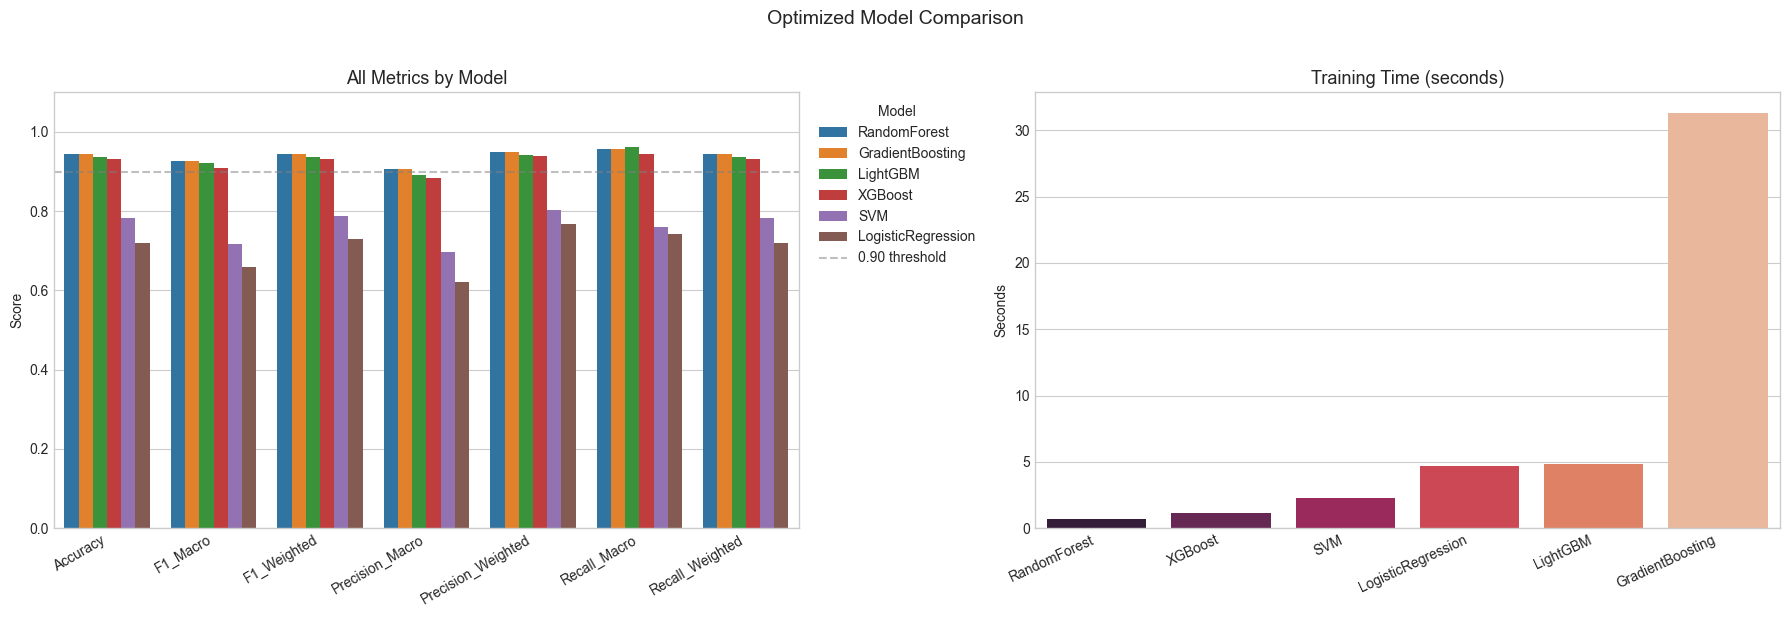

✓ Results saved.


In [21]:
plt.style.use('seaborn-v0_8-whitegrid')

METRIC_COLS = ['Accuracy', 'F1_Macro', 'F1_Weighted',
               'Precision_Macro', 'Precision_Weighted',
               'Recall_Macro', 'Recall_Weighted']

plot_df = results_df.melt(id_vars=['Model'], value_vars=METRIC_COLS,
                          var_name='Metric', value_name='Score')

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(data=plot_df, x='Metric', y='Score', hue='Model', palette='tab10', ax=axes[0])
axes[0].axhline(0.9, color='gray', linestyle='--', alpha=0.5, label='0.90 threshold')
axes[0].set_title('All Metrics by Model', fontsize=13)
axes[0].set_ylim(0, 1.1)
axes[0].set_xlabel('')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha='right')
axes[0].legend(title='Model', bbox_to_anchor=(1.01, 1), loc='upper left')

time_df = results_df.sort_values('Train_Time_s', ascending=True)
sns.barplot(data=time_df, x='Model', y='Train_Time_s', palette='rocket', ax=axes[1])
axes[1].set_title('Training Time (seconds)', fontsize=13)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=25, ha='right')
axes[1].set_xlabel('')
axes[1].set_ylabel('Seconds')

plt.suptitle('Optimized Model Comparison', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('output/optimized_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

results_df.to_csv('output/optimized_model_results.csv', index=False)
print("✓ Results saved.")

## Cell 8 — Per-Class Performance & Confusion Matrix

PER-CLASS METRICS — Best Model: RandomForest
                            precision    recall  f1-score   support

   Balanced NPK Fertilizer       0.84      1.00      0.91        31
                   Compost       0.94      0.89      0.92        75
                       DAP       1.00      0.93      0.97       211
General Purpose Fertilizer       0.67      1.00      0.80         6
                    Gypsum       0.91      0.91      0.91        11
                      Lime       0.95      1.00      0.97        36
         Muriate of Potash       0.95      0.85      0.89        65
        Organic Fertilizer       0.90      1.00      0.95        19
                      Urea       1.00      1.00      1.00        31
Water Retaining Fertilizer       0.91      0.99      0.95       135

                  accuracy                           0.95       620
                 macro avg       0.91      0.96      0.93       620
              weighted avg       0.95      0.95      0.95       620



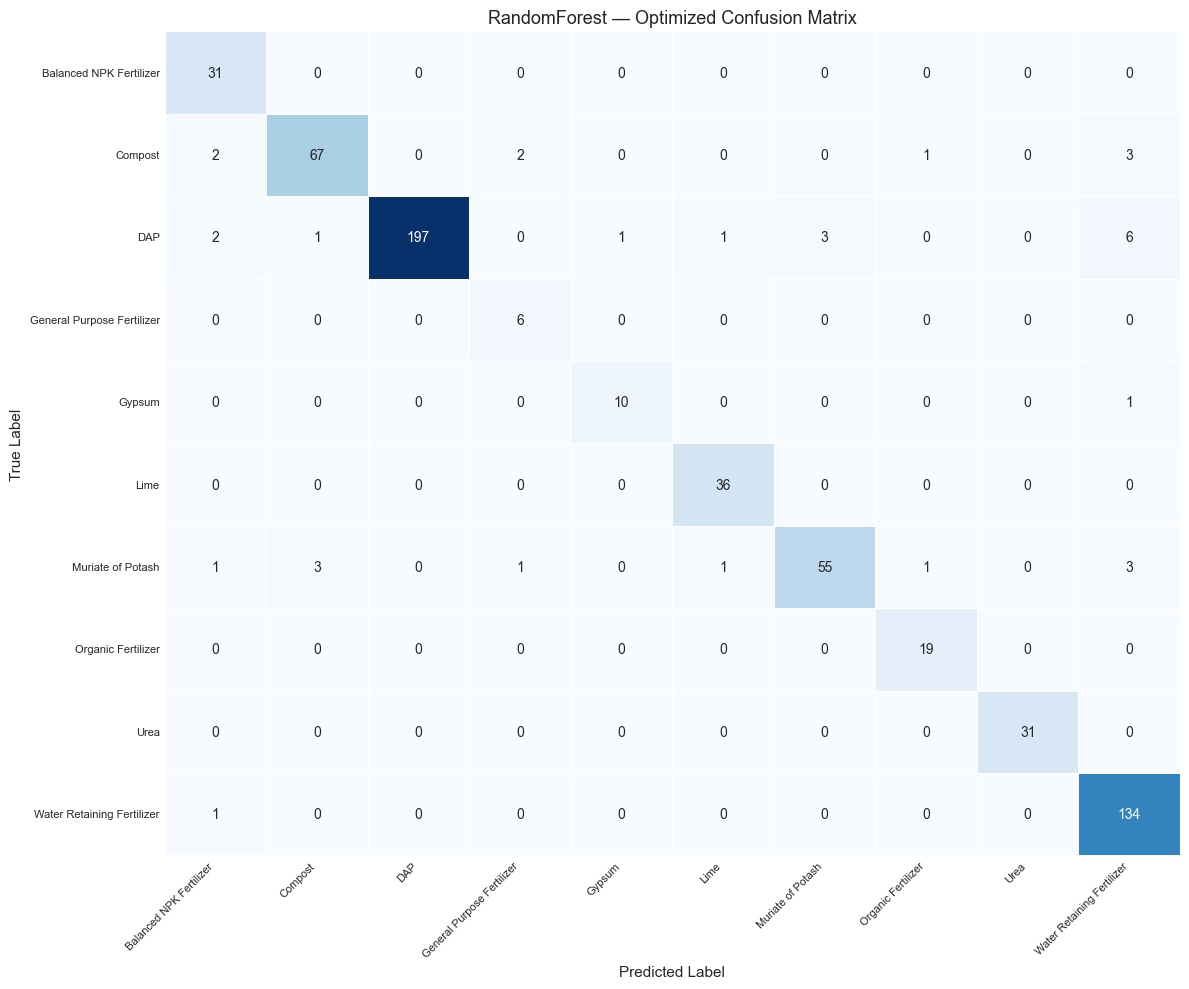

In [22]:
best_name  = results_df.iloc[0]['Model']
best_model = fitted_models[best_name]
X_te_best  = X_test_scaled if best_name in SCALED_MODELS else X_test_arr

y_pred_best  = best_model.predict(X_te_best)
target_names = [CLASS_MAP[i] for i in range(N_CLASSES)]

print("=" * 70)
print(f"PER-CLASS METRICS — Best Model: {best_name}")
print("=" * 70)
print(classification_report(y_test, y_pred_best, target_names=target_names, zero_division=0))

recalls      = pd.Series(recall_score(y_test, y_pred_best, average=None, zero_division=0), index=target_names)
CLASS_MAP_INV = {v: k for k, v in CLASS_MAP.items()}

print("⚠️  Classes with Recall < 0.80:")
for cls, rec in recalls[recalls < 0.80].items():
    n_train = np.sum(y_train == CLASS_MAP_INV[cls])
    print(f"   • {cls} | Recall: {rec:.3f} | Train samples: {n_train}")

cm    = confusion_matrix(y_test, y_pred_best)
cm_df = pd.DataFrame(cm, index=target_names, columns=target_names)

plt.figure(figsize=(12, 10))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', linewidths=0.5,
            cbar=False, xticklabels=target_names, yticklabels=target_names)
plt.title(f'{best_name} — Optimized Confusion Matrix', fontsize=13)
plt.xlabel('Predicted Label', fontsize=11)
plt.ylabel('True Label', fontsize=11)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig('output/cm_optimized_best.png', dpi=150)
plt.show()

## Cell 9 — Compute SHAP Values

In [23]:
feature_names = X_test.columns.tolist()
feature_arr   = np.array(feature_names)
shap_values   = {}
explainers    = {}

TREE_MODELS   = {'RandomForest', 'XGBoost', 'LightGBM'}
GB_MODELS     = {'GradientBoosting'}
LINEAR_MODELS = {'LogisticRegression'}
KERNEL_MODELS = {'SVM'}

for name, model in fitted_models.items():
    print(f"⏳ Computing SHAP for {name}...")

    if name in TREE_MODELS:
        explainer = shap.TreeExplainer(model)
        sv = explainer.shap_values(X_test_arr)
        shap_values[name] = sv

    elif name in GB_MODELS:
        background = shap.sample(X_test_arr, 100, random_state=RANDOM_STATE)
        explainer  = shap.Explainer(model.predict_proba, background, feature_names=feature_names)
        sv = explainer(X_test_arr)
        shap_values[name] = sv.values

    elif name in LINEAR_MODELS:
        masker    = shap.maskers.Independent(X_train_scaled, max_samples=200)
        explainer = shap.LinearExplainer(model, masker)
        sv = explainer(X_test_scaled)
        shap_values[name] = sv.values

    elif name in KERNEL_MODELS:
        print(f"   ⚠ KernelExplainer is slow — using 50-sample subsample for {name}.")
        background = shap.sample(X_train_scaled, 50, random_state=RANDOM_STATE)
        explainer  = shap.KernelExplainer(model.predict_proba, background)
        rng        = np.random.RandomState(RANDOM_STATE)
        sample_idx = rng.choice(len(X_test_scaled), 50, replace=False)
        sv = explainer.shap_values(X_test_scaled[sample_idx])
        shap_values[name] = sv

    explainers[name] = explainer
    print(f"✓ SHAP done for {name}")


def get_mean_abs_shap(sv):
    if isinstance(sv, list):
        return np.mean([np.abs(c).mean(axis=0) for c in sv], axis=0)
    arr = np.array(sv)
    if arr.ndim == 3:
        return np.abs(arr).mean(axis=(0, 2))
    return np.abs(arr).mean(axis=0)

⏳ Computing SHAP for RandomForest...
✓ SHAP done for RandomForest
⏳ Computing SHAP for GradientBoosting...


PermutationExplainer explainer: 621it [06:46,  1.49it/s]                                                      


✓ SHAP done for GradientBoosting
⏳ Computing SHAP for XGBoost...
✓ SHAP done for XGBoost
⏳ Computing SHAP for LightGBM...
✓ SHAP done for LightGBM
⏳ Computing SHAP for SVM...
   ⚠ KernelExplainer is slow — using 50-sample subsample for SVM.


100%|█████████████████████████████████████████████████████████████████████████| 50/50 [03:21<00:00,  4.03s/it]

✓ SHAP done for SVM
⏳ Computing SHAP for LogisticRegression...
✓ SHAP done for LogisticRegression


## Cell 10 — SHAP Feature Importance: All Models Grid

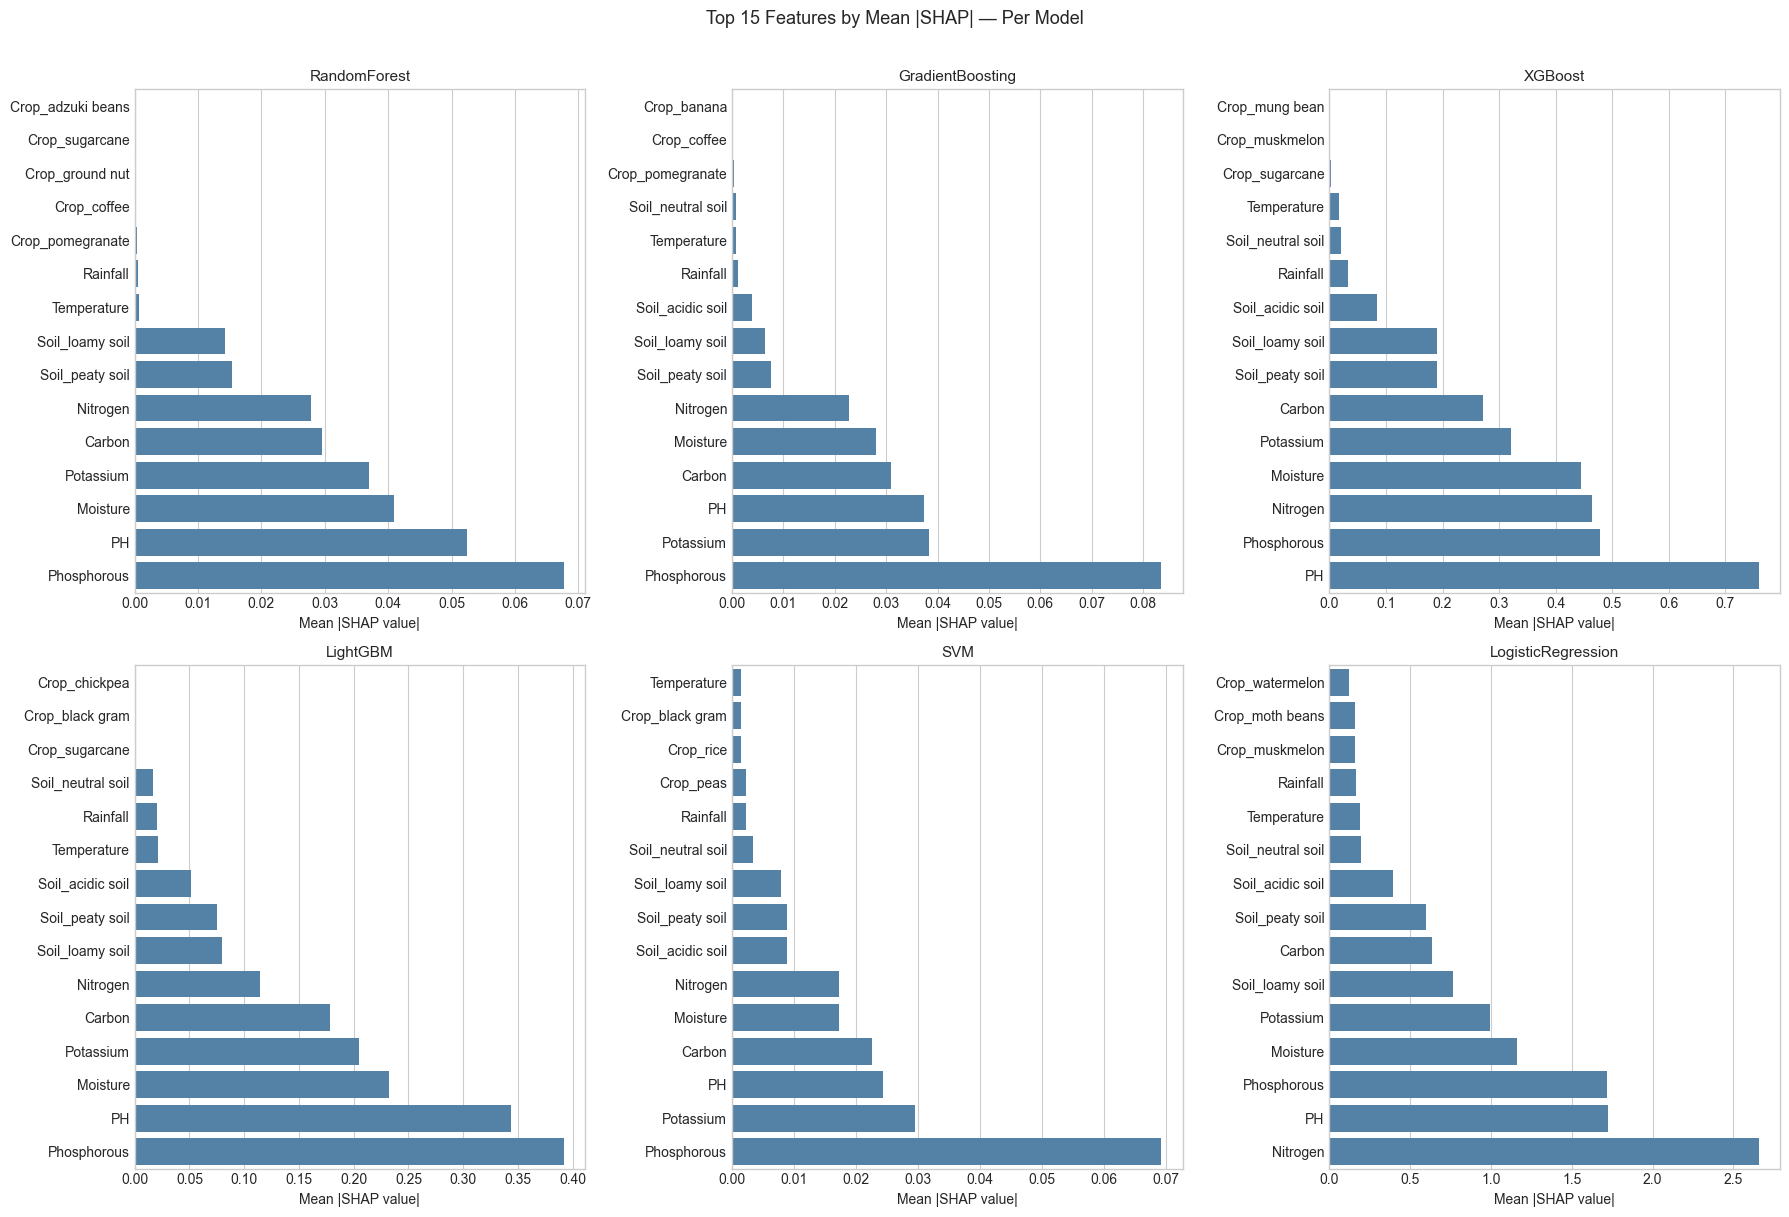

In [24]:
n_models = len(shap_values)
n_cols   = 3
n_rows   = (n_models + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 6 * n_rows))
axes = axes.flatten()

for ax, (name, sv) in zip(axes, shap_values.items()):
    mean_abs = get_mean_abs_shap(sv)
    top_idx  = np.argsort(mean_abs)[-15:]
    shap_df  = pd.DataFrame({
        'Feature':     feature_arr[top_idx],
        'Mean |SHAP|': mean_abs[top_idx],
    }).sort_values('Mean |SHAP|')

    sns.barplot(data=shap_df, x='Mean |SHAP|', y='Feature', color='steelblue', ax=ax)
    ax.set_title(name, fontsize=11)
    ax.set_xlabel('Mean |SHAP value|')
    ax.set_ylabel('')

for ax in axes[n_models:]:
    ax.set_visible(False)

plt.suptitle('Top 15 Features by Mean |SHAP| — Per Model', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('output/shap_importance_all_models.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 11 — SHAP Feature Importance: Best Model

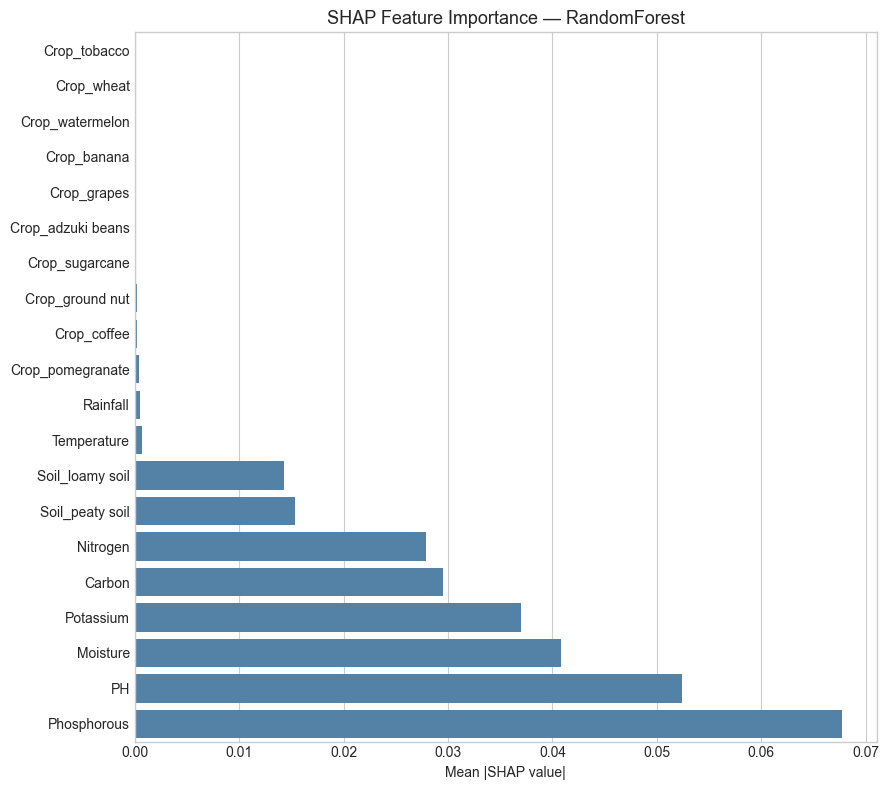

In [25]:
mean_abs_best = get_mean_abs_shap(shap_values[best_name])
top_idx       = np.argsort(mean_abs_best)[-20:]

shap_df = pd.DataFrame({
    'Feature':     feature_arr[top_idx],
    'Mean |SHAP|': mean_abs_best[top_idx],
}).sort_values('Mean |SHAP|')

plt.figure(figsize=(9, 8))
sns.barplot(data=shap_df, x='Mean |SHAP|', y='Feature', color='steelblue')
plt.title(f'SHAP Feature Importance — {best_name}', fontsize=13)
plt.xlabel('Mean |SHAP value|')
plt.ylabel('')
plt.tight_layout()
plt.savefig('output/shap_summary_best.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 12 — Spearman Rank Correlation of Feature Importances

In [26]:
importance_dict = {name: get_mean_abs_shap(sv) for name, sv in shap_values.items()}
importance_df   = pd.DataFrame(importance_dict, index=feature_names)
model_names     = list(importance_dict.keys())

print("📐 Spearman Rank Correlation of Feature Importances:")
for i in range(len(model_names)):
    for j in range(i + 1, len(model_names)):
        corr, pval = spearmanr(importance_df[model_names[i]], importance_df[model_names[j]])
        print(f"   {model_names[i]} ↔ {model_names[j]}: ρ = {corr:.3f} (p={pval:.3e})")

📐 Spearman Rank Correlation of Feature Importances:
   RandomForest ↔ GradientBoosting: ρ = 0.845 (p=5.776e-13)
   RandomForest ↔ XGBoost: ρ = 0.652 (p=1.615e-06)
   RandomForest ↔ LightGBM: ρ = 0.540 (p=1.552e-04)
   RandomForest ↔ SVM: ρ = 0.523 (p=2.739e-04)
   RandomForest ↔ LogisticRegression: ρ = 0.531 (p=2.075e-04)
   GradientBoosting ↔ XGBoost: ρ = 0.758 (p=2.581e-09)
   GradientBoosting ↔ LightGBM: ρ = 0.630 (p=4.649e-06)
   GradientBoosting ↔ SVM: ρ = 0.726 (p=2.478e-08)
   GradientBoosting ↔ LogisticRegression: ρ = 0.639 (p=3.111e-06)
   XGBoost ↔ LightGBM: ρ = 0.797 (p=9.352e-11)
   XGBoost ↔ SVM: ρ = 0.779 (p=4.582e-10)
   XGBoost ↔ LogisticRegression: ρ = 0.751 (p=4.194e-09)
   LightGBM ↔ SVM: ρ = 0.658 (p=1.207e-06)
   LightGBM ↔ LogisticRegression: ρ = 0.768 (p=1.183e-09)
   SVM ↔ LogisticRegression: ρ = 0.637 (p=3.260e-06)


## Cell 13 — Model Disagreement Analysis

In [27]:
preds = {}
for name, model in fitted_models.items():
    X_ev        = X_test_scaled if name in SCALED_MODELS else X_test_arr
    preds[name] = model.predict(X_ev)

pred_df              = pd.DataFrame(preds)
pred_df['true']      = y_test
model_names          = list(fitted_models.keys())
pred_df['all_agree'] = pred_df[model_names].apply(lambda row: len(set(row)) == 1, axis=1)

disagreement_rate = (~pred_df['all_agree']).mean()
disagreements     = pred_df[~pred_df['all_agree']].copy()
disagreements['any_correct'] = disagreements.apply(
    lambda r: r['true'] in [r[m] for m in model_names], axis=1
)

print(f"\n🔍 Samples where models disagree: {(~pred_df['all_agree']).sum()} / {len(pred_df)} ({disagreement_rate:.1%})")
print(f"   → At least one model correct: {disagreements['any_correct'].mean():.1%}")
print(f"   → All models wrong:           {(~disagreements['any_correct']).mean():.1%}")

print("\n📊 Disagreements by true class:")
print(
    disagreements.groupby('true').size()
    .rename(index=CLASS_MAP)
    .sort_values(ascending=False)
    .to_string()
)


🔍 Samples where models disagree: 187 / 620 (30.2%)
   → At least one model correct: 95.7%
   → All models wrong:           4.3%

📊 Disagreements by true class:
true
Water Retaining Fertilizer    51
DAP                           51
Compost                       23
Muriate of Potash             19
Lime                          11
Urea                          10
Organic Fertilizer             9
Balanced NPK Fertilizer        7
Gypsum                         3
General Purpose Fertilizer     3


## Cell 14 — Pairwise Cohen's Kappa Heatmap

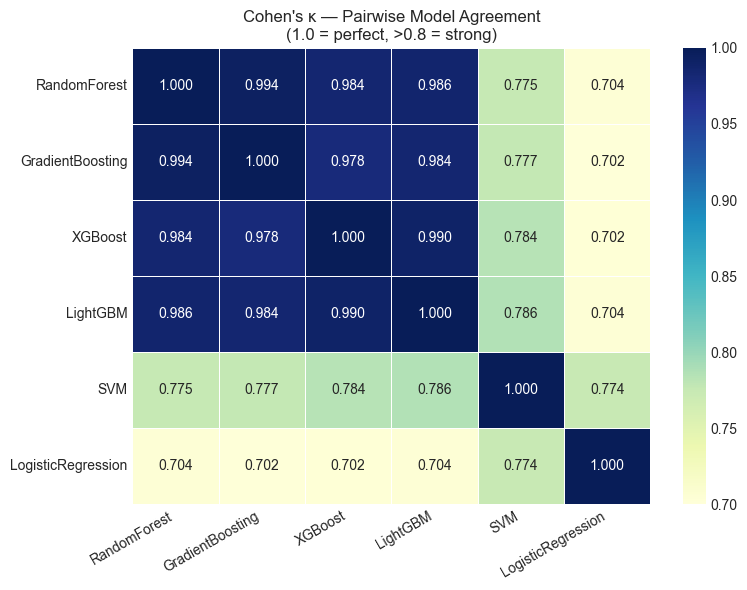

In [28]:
kappa_matrix = pd.DataFrame(index=model_names, columns=model_names, dtype=float)
for m1 in model_names:
    for m2 in model_names:
        kappa_matrix.loc[m1, m2] = cohen_kappa_score(preds[m1], preds[m2])

plt.figure(figsize=(8, 6))
sns.heatmap(
    kappa_matrix.astype(float), annot=True, fmt='.3f',
    cmap='YlGnBu', vmin=0.7, vmax=1.0, linewidths=0.5
)
plt.title("Cohen's κ — Pairwise Model Agreement\n(1.0 = perfect, >0.8 = strong)")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('output/model_agreement_kappa.png', dpi=150)
plt.show()